# Предсказуемость межгосударственных конфликтов по медиаданным

**Итоговый отчёт.** 37 вооружённых столкновений между государствами, 2013–2026, данные GDELT 1.0 Event Export.

---

## О чём работа

Исходная гипотеза звучала так: **перед началом военной агрессии тон и накал новостей об этой паре стран меняются заранее, и по ним можно предсказать нападение.**

Гипотеза проверялась дважды. Сначала на двух кейсах — США-Венесуэла и США-Иран — и там не подтвердилась. Этот отчёт проверяет её на выборке в восемнадцать раз больше, с контрольной группой, которой в первой версии не было вообще.

## Что получилось, в трёх строчках

1. **Тон новостей войну не предсказывает.** На 37 войнах исходная гипотеза отвергнута окончательно.
2. **Объём освещения — предсказывает.** Перед столкновением поток новостей о паре государств растёт, и этот рост отличим от обычного шума.
3. **Практическая ценность ограничена, но реальна.** Правило ловит две войны из пяти при одной ложной тревоге на шестнадцать спокойных периодов и повышает оценку риска примерно в шесть раз. Медианное упреждение — 14 дней.

## 1. Данные и дизайн исследования

### Откуда кейсы

Размечено по аналитическому перечню межгосударственных вооружённых эпизодов 2013–2026 годов (39 позиций), сверенному по открытым источникам. При сверке обнаружилась одна неверная дата и шесть неточных:

| эпизод | было | стало | почему |
|---|---|---|---|
| Аннексия Крыма | 20.02.2014 | 27.02.2014 | 20 февраля — дата на российской медали; парламент Крыма захвачен 27-го |
| Война в Донбассе | апрель 2014 | 12.04.2014 | захват Славянска группой Гиркина |
| Чумар | сентябрь 2014 | 16.09.2014 | начало 16-дневного противостояния |
| Платформа HYSY-981 | май 2014 | 01.05.2014 | Вьетнам обнаружил платформу в спорных водах |
| «Весенний щит» | февраль 2020 | 27.02.2020 | авиаудар в Балюне, 33 погибших |
| Таиланд — Камбоджа | декабрь 2025 | 07.12.2025 | перестрелка 7-го, авиаудары 8-го |
| ДР Конго — Руанда | «с 2022 года» | 23.01.2025 | наступление на Гому, участие войск Руанды задокументировано ООН |

Дополнительно включены три кейса из нашей прежней работы, которых в перечне нет: Балакот-2019, Йемен-2015, Венесуэла-2026.

### Что отсеяно и почему

| фильтр | убрано | зачем |
|---|---|---|
| только известный день | 0 после сверки | день X с точностью до месяца делает окно бессмысленным |
| государство против государства | 3 | Арцах, «Хезболла», ПОЛИСАРИО — не регулярные армии |
| морские инциденты | 2 | нет единой даты, десятки эпизодов за три года |
| повторный эпизод пары в пределах 60 дней | 4 | их фон состоит из предыдущей войны: это «война перед войной» |
| окно вне дневных файлов GDELT | 1 | до апреля 2013 суточных файлов нет |

### Ключевые решения дизайна

**День X** — дата начала вооружённого столкновения. **Окно данных кончается за день до него**: мы принципиально не заглядываем в будущее.

**Контрольные окна** — главное отличие от первой версии работы. Для каждой войны построено окно той же пары государств за год (два, три) до дня X, при условии что ни один известный эпизод этой пары не попадает ни в окно, ни в буфер длиной в окно по обе стороны. Это отрицательные примеры: без них сравнивать не с чем, и первая версия работы именно этим и страдала.

Итог: **37 войн, 34 контроля, 20 пар государств, 71 наблюдение.**

In [1]:
import pandas as pd, numpy as np, json
from scipy import stats
import matplotlib, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
matplotlib.rcParams['figure.dpi'] = 120

# палитра отчёта
SURFACE, INK, INK2, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS, WARM, COOL = '#e1e0d9', '#c3c2b7', '#e34948', '#2a78d6'
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':9,
                     'axes.facecolor':SURFACE,'figure.facecolor':SURFACE,
                     'axes.edgecolor':AXIS,'text.color':INK})

F = pd.read_csv('data/run_features.csv')
L = pd.read_csv('data/run_lead_times_v3.csv')
y = F.метка.values

print(f'наблюдений: {len(F)} | войн: {y.sum()} | контролей: {(y==0).sum()} | пар государств: {F.пара.nunique()}')
print(f'событий в окнах суммарно: {F.events_week.sum():,.0f} (только последние недели)'.replace(',', ' '))

наблюдений: 71 | войн: 37 | контролей: 34 | пар государств: 20
событий в окнах суммарно: 90 916 (только последние недели)


### Признаки

Все признаки считаются на конец окна: **последняя неделя перед днём X против четырёх недель фона той же пары**.

| признак | что означает |
|---|---|
| `z_tone` | насколько тон последней недели хуже обычного для этой пары, в стандартных отклонениях |
| `z_vol` | насколько объём новостей последней недели выше обычного, в стандартных отклонениях |
| `vol_ratio` | во сколько раз объём последней недели выше фона |
| `log_vol` | абсолютный уровень освещения за неделю, логарифм |
| `z_hard`, `z_force`, `z_mat` | доли жёстких, силовых и материально-конфликтных событий, тоже в сигмах |
| `slope21_tone` | наклон тренда тона за последнюю 21 день |

Знаки везде выставлены так, что **больше значит тревожнее**.

## 2. Главный результат: парное сравнение

Контроль строился под конкретную войну той же пары, поэтому сравнивать надо парами. Парный тест убирает различия между парами государств — об Иране и США пишут в сотню раз больше, чем о Киргизии и Таджикистане, и в непарном сравнении это различие маскирует сигнал.

In [2]:
W, Ctl = F[F.метка==1], F[F.метка==0].copy()
Ctl['к'] = Ctl.название.str.extract(r'контроль к «(.+?)»\s*\(−\d')[0]
пары = []
for _, c in Ctl.iterrows():
    m = W[(W.пара==c.пара) & (W.название==c.к)]
    if len(m)==1:
        пары.append((c.пара, str(c.день_X), m.iloc[0], c))

CAND = ['z_tone','z_gold','z_mat','z_hard','z_force','z_vol','vol_ratio','log_vol','slope21_tone']
строки = []
for c in CAND:
    d = np.array([w[c]-ct[c] for _,_,w,ct in пары], float)
    st = stats.wilcoxon(d)
    строки.append(dict(признак=c, выше_у_войны=f'{int((d>0).sum())}/{len(d)}',
                       медиана_разницы=round(float(np.median(d)),3),
                       p=round(float(st.pvalue),5),
                       размер_эффекта=round(float(d.mean()/d.std(ddof=1)),2)))
P = pd.DataFrame(строки).sort_values('p')
порог = 0.05/len(CAND)
P['проходит_Бонферрони'] = np.where(P.p < порог, 'да', '')
print(P.to_string(index=False))
print(f'\nПоправка Бонферрони на {len(CAND)} признаков: значимо при p < {порог:.5f}')

     признак выше_у_войны  медиана_разницы       p  размер_эффекта проходит_Бонферрони
     log_vol        29/34            0.732 0.00001            0.93                  да
   vol_ratio        22/34            0.317 0.01247            0.46                    
slope21_tone        22/34            0.058 0.02058            0.40                    
      z_tone        21/34            1.149 0.02609            0.42                    
       z_vol        23/34            1.170 0.06433            0.32                    
     z_force        20/34            0.243 0.19518            0.25                    
      z_hard        15/34           -0.050 0.66714            0.24                    
       z_mat        17/34            0.115 0.83952           -0.05                    
      z_gold        18/34            0.111 0.97308            0.06                    

Поправка Бонферрони на 9 признаков: значимо при p < 0.00556


**Читается так.** Из девяти признаков поправку на множественные сравнения проходит ровно один: `log_vol` — объём освещения пары за последнюю неделю. У **29 войн из 34** он выше, чем у своего же контроля. Вероятность получить такой перекос случайно — одна стотысячная.

Тон (`z_tone`) идёт с p = 0.026 — это значимо только без поправки, то есть на уровне «могло и повезти».

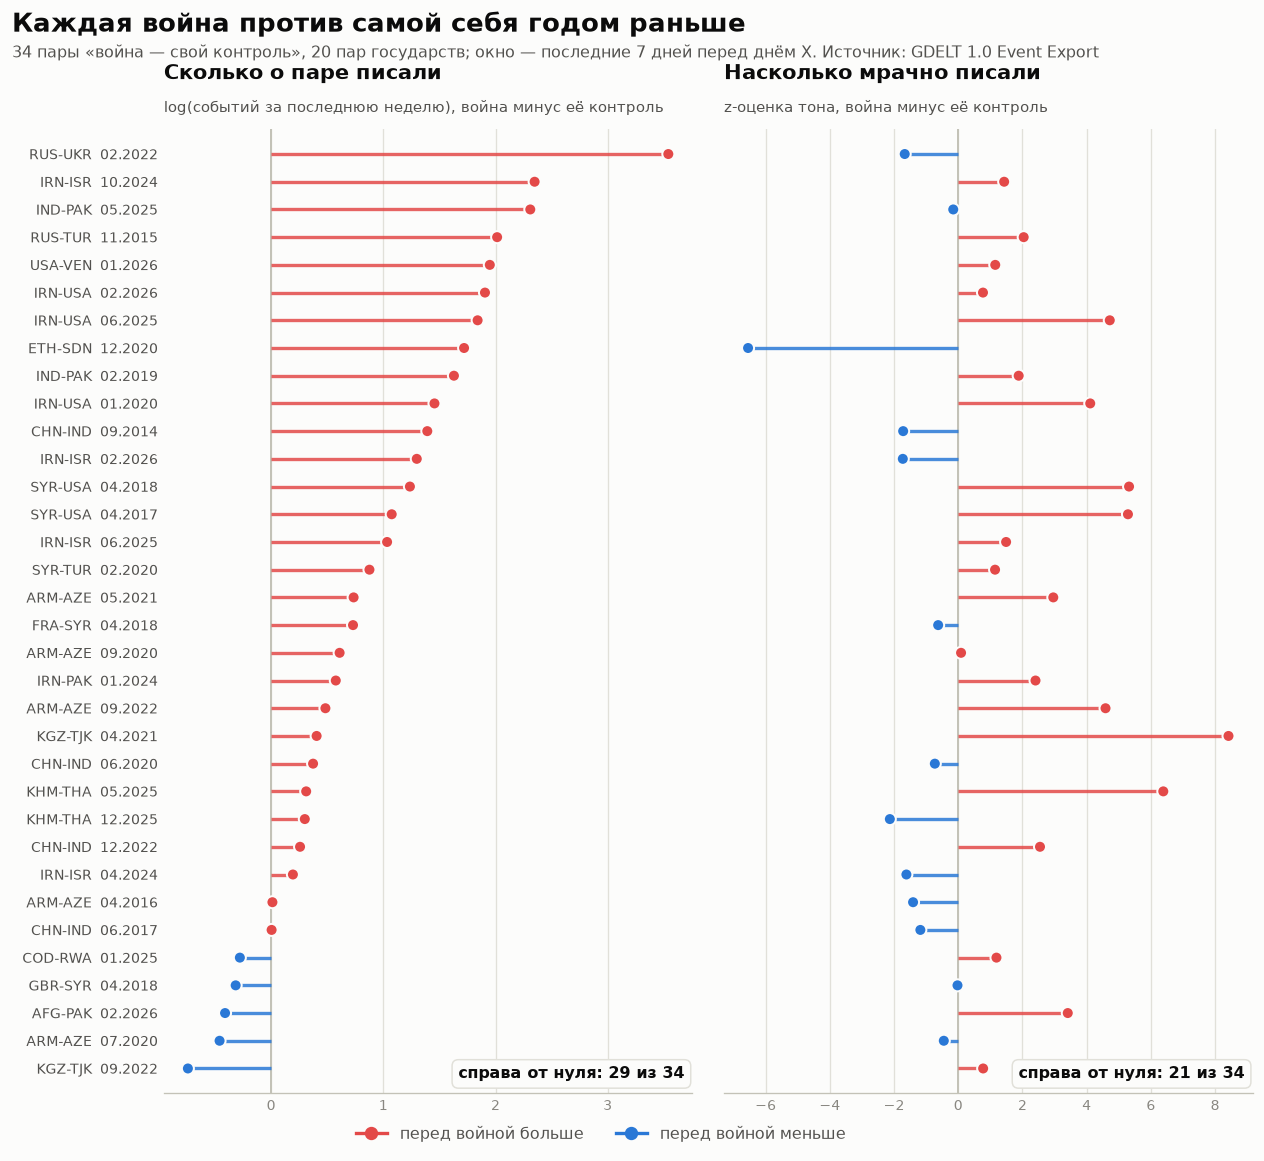

In [3]:
# График: каждая война против своего же контроля
Д = pd.DataFrame([dict(ярлык=f"{p}  {pd.to_datetime(w.день_X).strftime('%m.%Y')}",
                       объём=w.log_vol-ct.log_vol, тон=w.z_tone-ct.z_tone)
                  for p,_,w,ct in пары]).sort_values('объём').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 9.8), sharey=True, gridspec_kw=dict(wspace=0.06))
yy = np.arange(len(Д))
for ax, col, title, sub in [
    (axes[0], 'объём', 'Сколько о паре писали',
     'log(событий за последнюю неделю), война минус её контроль'),
    (axes[1], 'тон', 'Насколько мрачно писали',
     'z-оценка тона, война минус её контроль')]:
    v = Д[col].values
    cols = [WARM if x>0 else COOL for x in v]
    ax.hlines(yy, 0, v, color=cols, linewidth=2, alpha=.85, zorder=2)
    ax.scatter(v, yy, s=52, color=cols, zorder=3, edgecolor=SURFACE, linewidth=1.2)
    ax.axvline(0, color=AXIS, linewidth=1.2, zorder=1)
    ax.xaxis.grid(True, color=GRID, linewidth=.8, zorder=0); ax.set_axisbelow(True)
    for s in ('top','right','left'): ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_color(AXIS)
    ax.tick_params(colors=MUTED, length=0, labelsize=8.5)
    ax.set_title(title, fontsize=12.5, color=INK, loc='left', pad=30, weight='bold')
    ax.text(0, 1.014, sub, transform=ax.transAxes, fontsize=9, color=INK2, va='bottom')
    ax.text(0.985, 0.012, f'справа от нуля: {int((v>0).sum())} из {len(v)}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9.5,
            color=INK, weight='bold',
            bbox=dict(boxstyle='round,pad=0.4', fc=SURFACE, ec=GRID, lw=.9))
axes[0].set_yticks(yy); axes[0].set_yticklabels(Д.ярлык, fontsize=8.2, color=INK2)
axes[0].set_ylim(-0.9, len(Д)-0.1)
fig.legend(handles=[Line2D([],[],color=WARM,lw=2,marker='o',ms=7,label='перед войной больше'),
                    Line2D([],[],color=COOL,lw=2,marker='o',ms=7,label='перед войной меньше')],
           loc='lower center', ncol=2, frameon=False, fontsize=9.5,
           bbox_to_anchor=(0.5, 0.004), labelcolor=INK2)
fig.suptitle('Каждая война против самой себя годом раньше',
             fontsize=15.5, color=INK, weight='bold', x=0.062, ha='left', y=0.978)
fig.text(0.062, 0.950, '34 пары «война — свой контроль», 20 пар государств; '
         'окно — последние 7 дней перед днём X. Источник: GDELT 1.0 Event Export',
         fontsize=9.5, color=INK2, ha='left', va='top')
fig.subplots_adjust(top=0.878, bottom=0.058, left=0.175, right=0.985)
plt.show()

Слева почти всё красное — освещение перед войной выше почти всегда. Справа каша: тон ведёт себя как попало.

Отдельно стоит посмотреть на выбросы. Самая длинная красная полоса слева — вторжение в Украину 2022: поток новостей о паре вырос настолько, что разница в логарифме превышает 3.5, то есть больше чем в тридцать раз. Синие полосы слева — пять войн, перед которыми освещение, наоборот, упало; среди них Афгано-пакистанская война 2026 года и бои в Товузском районе.

## 3. Проверка: это не артефакт растущего архива

У результата есть очевидное альтернативное объяснение. Контроли всегда на год раньше войн, а база GDELT со временем индексирует всё больше источников. Тогда «перед войной пишут больше» означало бы просто «в более позднем году пишут больше обо всём».

Проверяется это регрессией, где календарный год входит отдельным слагаемым, а различия между парами государств поглощены фиксированными эффектами.

In [4]:
def фикс_эффекты(df, цель):
    d = df.copy()
    d['год'] = pd.to_datetime(d.день_X).dt.year
    D = pd.get_dummies(d.пара, drop_first=True).astype(float)
    X = np.column_stack([np.ones(len(d)), d.метка.values.astype(float),
                         (d.год.values - d.год.mean()).astype(float), D.values])
    yv = d[цель].values.astype(float)
    b, *_ = np.linalg.lstsq(X, yv, rcond=None)
    r = yv - X @ b; dof = len(d) - X.shape[1]
    cov = (r @ r / dof) * np.linalg.pinv(X.T @ X); se = np.sqrt(np.diag(cov))
    out = {}
    for i, nm in [(1,'война'), (2,'год')]:
        t = b[i]/se[i]
        out[nm] = (b[i], 2*(1-stats.t.cdf(abs(t), dof)))
    return out

рез = []
for c in ['log_vol','vol_ratio','z_vol','z_tone']:
    fe = фикс_эффекты(F, c)
    рез.append(dict(признак=c,
                    эффект_войны=round(fe['война'][0],3), p_войны=round(fe['война'][1],4),
                    эффект_года=round(fe['год'][0],3), p_года=round(fe['год'][1],4)))
print(pd.DataFrame(рез).to_string(index=False))
b = рез[0]['эффект_войны']; g = рез[0]['эффект_года']
print(f'\nlog_vol: перед войной освещение выше на {np.expm1(b)*100:.0f}%,')
print(f'а календарный тренд равен {np.expm1(g)*100:+.1f}% в год — то есть архив не растёт, а слегка сжимается.')

  признак  эффект_войны  p_войны  эффект_года  p_года
  log_vol         0.966   0.0000       -0.074  0.0844
vol_ratio         0.789   0.0013       -0.150  0.0157
    z_vol         0.956   0.0368       -0.139  0.2341
   z_tone         0.977   0.0947        0.104  0.4868

log_vol: перед войной освещение выше на 163%,
а календарный тренд равен -7.1% в год — то есть архив не растёт, а слегка сжимается.


**Артефакт исключён.** Календарный коэффициент отрицательный, то есть в более поздние годы освещения в нашей выборке скорее меньше. А эффект «перед войной» после всех поправок остаётся: **плюс 163% к объёму освещения**, t = 5.9.

`vol_ratio` — версия, нормированная на собственный фон пары внутри того же окна и потому к росту архива нечувствительная по построению, — тоже значима (p = 0.0013). Тон не значим (p = 0.095).

## 4. Тон: исходная гипотеза не подтвердилась

Ради полноты соберём всё, что мы знаем про тон, в одном месте.

In [5]:
def auc(yv, s):
    pos, neg = s[yv==1], s[yv==0]
    r = stats.rankdata(np.concatenate([pos, neg]))
    return (r[:len(pos)].sum() - len(pos)*(len(pos)+1)/2) / (len(pos)*len(neg))

v = F.z_tone.values.astype(float)
d_tone = np.array([w.z_tone-ct.z_tone for _,_,w,ct in пары], float)
al = v >= 1.0
итог_тон = pd.DataFrame([
    dict(проверка='парный тест (Вилкоксон)', результат=f'21 из 34, p = {stats.wilcoxon(d_tone).pvalue:.3f}',
         вывод='значимо только без поправки'),
    dict(проверка='поправка Бонферрони', результат='порог p < 0.0056', вывод='не проходит'),
    dict(проверка='с учётом пары государств', результат='p = 0.095', вывод='не значимо'),
    dict(проверка='AUC (ранжирование)', результат=f'{auc(y, v):.3f}', вывод='интервал накрывает 0.5'),
    dict(проверка='правило «тон хуже на 1σ», замер на конец окна',
         результат=f'ловит {al[y==1].mean():.0%} войн, ложных тревог {al[y==0].mean():.0%}',
         вывод='почти не различает'),
])
print(итог_тон.to_string(index=False))

                                     проверка                         результат                       вывод
                      парный тест (Вилкоксон)               21 из 34, p = 0.026 значимо только без поправки
                          поправка Бонферрони                  порог p < 0.0056                 не проходит
                     с учётом пары государств                         p = 0.095                  не значимо
                           AUC (ранжирование)                             0.629      интервал накрывает 0.5
правило «тон хуже на 1σ», замер на конец окна ловит 41% войн, ложных тревог 32%          почти не различает


Ни одна проверка тон не спасает. **Гипотеза, ради которой всё начиналось, отвергнута** — теперь уже на выборке, где отрицательный результат означает «эффекта нет», а не «данных не хватило».

Это важное уточнение. В первой версии работы, на двух кейсах, мы были способны заметить только гигантский эффект (d порядка 2.0). Сейчас выборка различает эффекты от d = 0.68. Тон не дотягивает и до этого.

## 5. От связи к правилу

Статистическая связь и работающая сигнализация — разные вещи. Связь у нас есть; теперь надо понять, что она даёт в виде правила «тревога или нет».

Правило проверяется не на конец окна, а **на всём его протяжении**: сигнал считается сработавшим, если порог был перейдён хотя бы в один день из тех, что доступны для расчёта. Так работала бы настоящая система мониторинга — она смотрит каждый день.

Вместе с войнами так же обсчитаны контрольные окна. Без них доля срабатываний в войнах бессмысленна: за 26 дней наблюдения у сигнала 26 попыток пересечь порог, и слабый порог шум пересекает почти всегда.

In [6]:
# три контроля, в чьё окно попал реальный эпизод с участием одной из стран пары
ГРЯЗНЫЕ = {('FRA-SYR','2017-04-14'), ('GBR-SYR','2017-04-14'), ('IRN-USA','2024-06-13')}
L['грязный'] = L.apply(lambda r: (r.пара, str(r.день_X)) in ГРЯЗНЫЕ, axis=1)
Lч = L[~L.грязный]

строки = []
for (f_, t_), g in Lч.groupby(['признак','порог'], sort=False):
    w_, c_ = g[g.метка==1], g[g.метка==0]
    a, b_ = int(w_.лид_тайм_дней.notna().sum()), int(c_.лид_тайм_дней.notna().sum())
    tpr, fpr = a/len(w_), b_/len(c_)
    p = stats.fisher_exact([[a, len(w_)-a],[b_, len(c_)-b_]])[1]
    строки.append(dict(правило=f'{f_} ≥ {t_}',
                       ловит_войн=f'{a}/{len(w_)} ({tpr:.0%})',
                       ложных_тревог=f'{b_}/{len(c_)} ({fpr:.0%})',
                       повышение_шансов=round(tpr/max(fpr,1e-9),1), p=round(p,4)))
R = pd.DataFrame(строки).sort_values('повышение_шансов', ascending=False)
print(R.to_string(index=False))

        правило  ловит_войн ложных_тревог  повышение_шансов      p
vol_ratio ≥ 2.5 15/37 (41%)     2/31 (6%)               6.3 0.0016
    z_vol ≥ 2.0 27/37 (73%)   14/31 (45%)               1.6 0.0261
vol_ratio ≥ 1.5 29/37 (78%)   18/31 (58%)               1.3 0.1130
   z_tone ≥ 2.0 20/37 (54%)   14/31 (45%)               1.2 0.6267
   z_tone ≥ 1.0 30/37 (81%)   23/31 (74%)               1.1 0.5647
    z_vol ≥ 1.0 32/37 (86%)   24/31 (77%)               1.1 0.3579


**Только одно правило работает.** `vol_ratio ≥ 2.5` — освещение последней недели выросло минимум в два с половиной раза относительно собственного четырёхнедельного фона пары.

Остальные срабатывают почти одинаково часто в войнах и в спокойное время. Строчка `z_tone ≥ 1.0` — ровно то правило, которое мы заморозили в первой версии работы: 81% против 74%, повышение шансов в 1.1 раза. Это отсутствие информации.

Естественная мысль «опустим порог, чтобы ловить больше» не работает: полнота растёт, ценность падает. Проверено и на объединении правил через «или» с честным отбором на отложенных парах — лучшая комбинация даёт 78% полноты при 58% ложных тревог, то есть повышение шансов в 1.3 раза вместо 6.3.

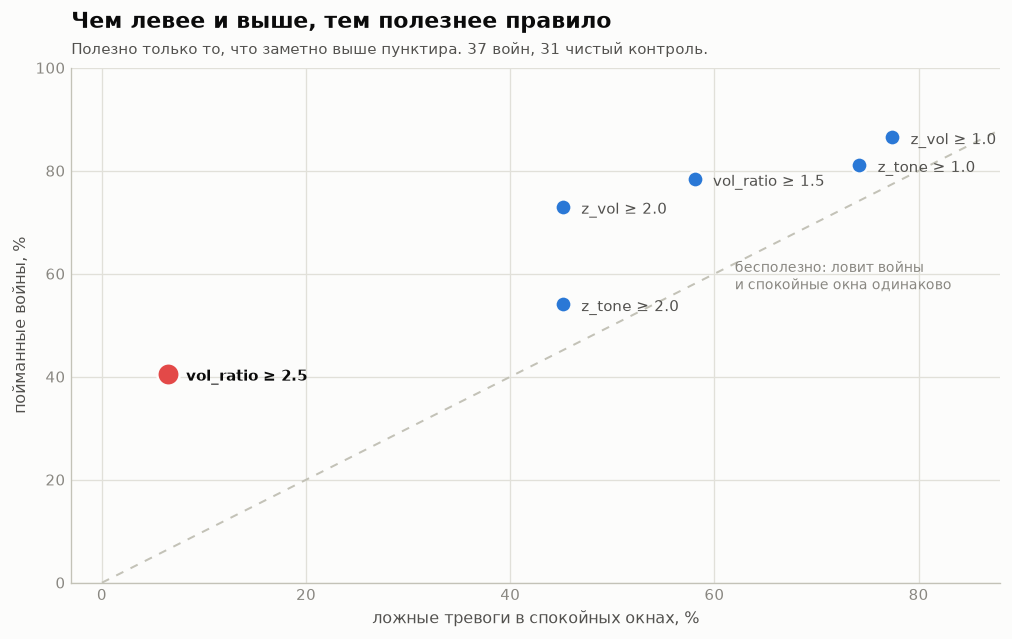

In [7]:
fig, ax = plt.subplots(figsize=(8.6, 5.4))
for (f_, t_), g in Lч.groupby(['признак','порог'], sort=False):
    w_, c_ = g[g.метка==1], g[g.метка==0]
    tpr, fpr = w_.лид_тайм_дней.notna().mean(), c_.лид_тайм_дней.notna().mean()
    главное = (f_=='vol_ratio' and t_==2.5)
    ax.scatter(fpr*100, tpr*100, s=180 if главное else 95,
               color=WARM if главное else COOL, zorder=3,
               edgecolor=SURFACE, linewidth=1.5)
    ax.annotate(f'{f_} ≥ {t_}', (fpr*100, tpr*100),
                textcoords='offset points', xytext=(11, -4),
                fontsize=9, color=INK if главное else INK2,
                weight='bold' if главное else 'normal')
ax.plot([0,100],[0,100], color=AXIS, lw=1.2, ls=(0,(4,4)), zorder=1)
ax.text(62, 57, 'бесполезно: ловит войны\nи спокойные окна одинаково',
        fontsize=8.6, color=MUTED, ha='left')
ax.set_xlim(-3, 88); ax.set_ylim(0, 100)
ax.grid(True, color=GRID, linewidth=.8, zorder=0); ax.set_axisbelow(True)
for s in ('top','right'): ax.spines[s].set_visible(False)
for s in ('left','bottom'): ax.spines[s].set_color(AXIS)
ax.tick_params(colors=MUTED, length=0)
ax.set_xlabel('ложные тревоги в спокойных окнах, %', color=INK2, fontsize=9.5)
ax.set_ylabel('пойманные войны, %', color=INK2, fontsize=9.5)
ax.set_title('Чем левее и выше, тем полезнее правило', fontsize=13,
             color=INK, loc='left', pad=24, weight='bold')
ax.text(0, 1.02, 'Полезно только то, что заметно выше пунктира. 37 войн, 31 чистый контроль.',
        transform=ax.transAxes, fontsize=9, color=INK2, va='bottom')
plt.tight_layout(); plt.show()

## 6. Находка: две «ложные тревоги» оказались настоящими

Разбор ошибок дал отдельный результат. Из четырёх ложных срабатываний объёмного правила два приходятся на контроли Франция–Сирия и Великобритания–Сирия за апрель 2017 года.

В их окно попадает **удар США по авиабазе Шайрат 7 апреля 2017 года**.

Это не ложная тревога, а дефект разметки. Проверка загрязнения искала эпизоды **той же пары**, а удар был по паре США–Сирия. Франция и Великобритания в нём не участвовали, но поток новостей о Сирии вырос, и «спокойное» окно спокойным не было.

Исправление: проверка теперь смотрит на эпизоды с участием **любой из двух стран** пары. Три контроля автоматически переехали на другие годы.

In [8]:
g = L[(L.признак=='vol_ratio') & (L.порог==2.5)]
для_таблицы = []
for имя, gg in [('как есть', g), ('без загрязнённых контролей', g[~g.грязный])]:
    w_, c_ = gg[gg.метка==1], gg[gg.метка==0]
    a, b_ = int(w_.лид_тайм_дней.notna().sum()), int(c_.лид_тайм_дней.notna().sum())
    tpr, fpr = a/len(w_), b_/len(c_)
    p = stats.fisher_exact([[a,len(w_)-a],[b_,len(c_)-b_]])[1]
    для_таблицы.append(dict(вариант=имя, ловит_войн=f'{a}/{len(w_)} ({tpr:.0%})',
                            ложных=f'{b_}/{len(c_)} ({fpr:.0%})',
                            повышение_шансов=round(tpr/fpr,1), p=round(p,4)))
print(pd.DataFrame(для_таблицы).to_string(index=False))

print('\nПарный результат по объёму от чистки не пострадал:')
for имя, sel in [('как есть', пары),
                 ('без загрязнённых', [x for x in пары if (x[0],x[1]) not in ГРЯЗНЫЕ])]:
    d = np.array([w.log_vol-ct.log_vol for _,_,w,ct in sel], float)
    print(f'  {имя:<18} log_vol выше у войны {int((d>0).sum())}/{len(d)}, '
          f'p = {stats.wilcoxon(d).pvalue:.5f}, d = {d.mean()/d.std(ddof=1):.2f}')

                   вариант  ловит_войн     ложных  повышение_шансов      p
                  как есть 15/37 (41%) 4/34 (12%)               3.4 0.0076
без загрязнённых контролей 15/37 (41%)  2/31 (6%)               6.3 0.0016

Парный результат по объёму от чистки не пострадал:
  как есть           log_vol выше у войны 29/34, p = 0.00001, d = 0.93
  без загрязнённых   log_vol выше у войны 27/31, p = 0.00001, d = 0.94


## 7. За сколько дней появляется сигнал

Лид-тайм — это число дней между первым срабатыванием сигнала и днём X.

У этой величины есть **потолок**, и о нём надо сказать прямо. Признаки требуют 35 дней истории на расчёт фона, а окно всего 60 дней. Значит, самая ранняя точка, где сигнал вообще можно посчитать, — 26-й день до дня X. Если сигнал уже горел там, настоящий лид-тайм больше, но насколько — не видно. Такие наблюдения помечены как цензурированные.

Сигнал появился заранее в 15 войнах из 37
Медиана 14 дней, квартили 10-26, диапазон 1-26
Уткнулись в потолок наблюдения: 4


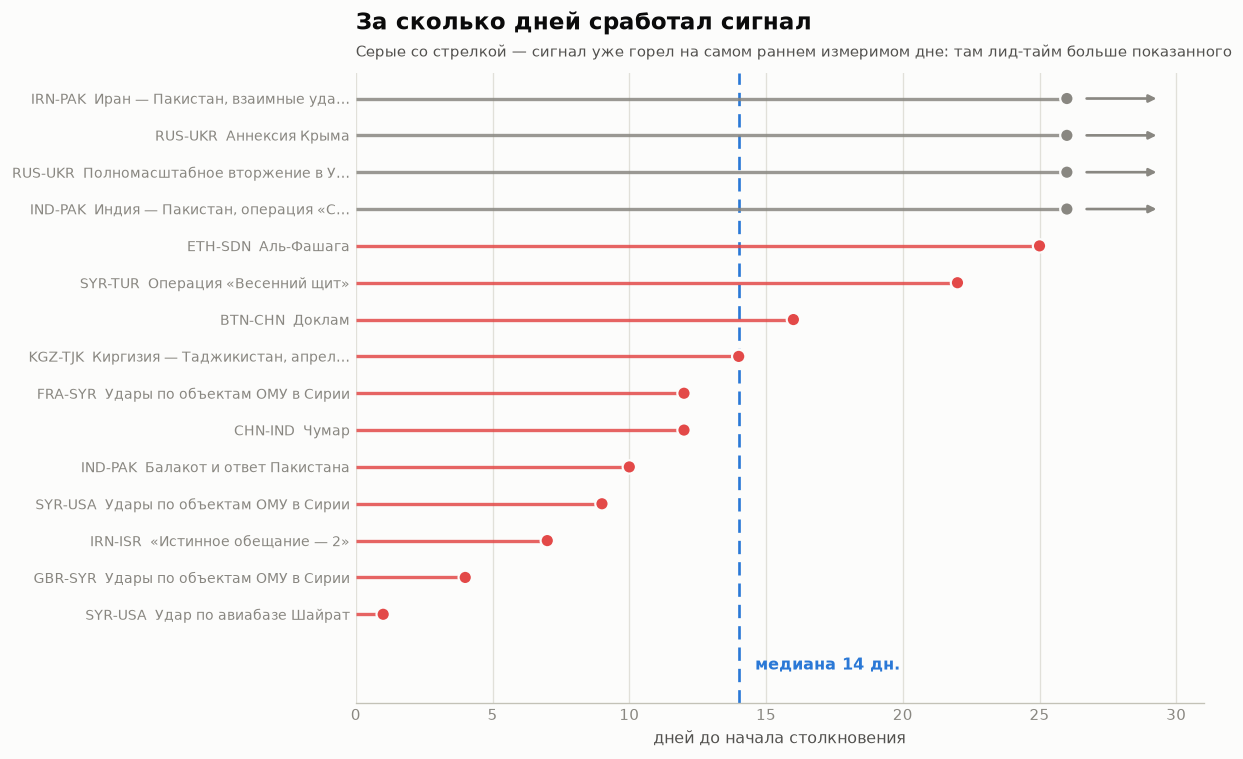

In [9]:
gv = L[(L.признак=='vol_ratio') & (L.порог==2.5) & (L.метка==1) & L.лид_тайм_дней.notna()]
gv = gv.sort_values('лид_тайм_дней')
got = gv.лид_тайм_дней
print(f'Сигнал появился заранее в {len(gv)} войнах из {(L[L.метка==1])[["пара","день_X"]].drop_duplicates().shape[0]}')
print(f'Медиана {got.median():.0f} дней, квартили {got.quantile(.25):.0f}-{got.quantile(.75):.0f}, '
      f'диапазон {got.min():.0f}-{got.max():.0f}')
print(f'Уткнулись в потолок наблюдения: {int(gv.цензурировано.sum())}')

fig, ax = plt.subplots(figsize=(10.2, 6.4))
yy = np.arange(len(gv))
цвета = [MUTED if c else WARM for c in gv.цензурировано]
ax.hlines(yy, 0, gv.лид_тайм_дней, color=цвета, linewidth=2, alpha=.85, zorder=2)
ax.scatter(gv.лид_тайм_дней, yy, s=64, color=цвета, zorder=3,
           edgecolor=SURFACE, linewidth=1.3)
for i, (_, r) in enumerate(gv.iterrows()):
    if r.цензурировано:
        ax.annotate('', xy=(r.лид_тайм_дней+3.4, i), xytext=(r.лид_тайм_дней+0.6, i),
                    arrowprops=dict(arrowstyle='-|>', color=MUTED, lw=1.6))
ax.axvline(float(got.median()), color=COOL, lw=1.6, ls=(0,(5,3)), zorder=1)
ax.text(float(got.median())+0.6, -1.5, f'медиана {got.median():.0f} дн.',
        color=COOL, fontsize=9.5, weight='bold')
ax.set_yticks(yy)
def _ярлык(r):
    н = r.название if len(r.название) <= 30 else r.название[:29] + '…'
    return f'{r.пара}  {н}'
ax.set_yticklabels([_ярлык(r) for _, r in gv.iterrows()],
                   fontsize=8.3, color=INK2)
ax.set_ylim(-2.4, len(gv)-0.3)
ax.set_xlim(0, float(gv.лид_тайм_дней.max()) + 5)
ax.xaxis.grid(True, color=GRID, linewidth=.8, zorder=0); ax.set_axisbelow(True)
for s in ('top','right','left'): ax.spines[s].set_visible(False)
ax.spines['bottom'].set_color(AXIS)
ax.tick_params(colors=MUTED, length=0)
ax.set_xlabel('дней до начала столкновения', color=INK2, fontsize=9.5)
ax.set_title('За сколько дней сработал сигнал', fontsize=13.5, color=INK,
             loc='left', pad=26, weight='bold')
ax.text(0, 1.02, 'Серые со стрелкой — сигнал уже горел на самом раннем измеримом дне: '
        'там лид-тайм больше показанного',
        transform=ax.transAxes, fontsize=9, color=INK2, va='bottom')
plt.tight_layout(); plt.show()

Четыре самых важных случая — Крым, вторжение 2022 года, «Синдур» и обмен ударами Иран–Пакистан — как раз те, где сигнал уже горел на границе видимости. Это прямой аргумент за сбор с окном в 120 дней: у нас, скорее всего, есть более раннее предупреждение, которого мы физически не видим.

## 8. Что это значит на практике

Три разных числа, которые постоянно путают между собой.

In [10]:
from statsmodels.stats.proportion import proportion_confint
tp, nw_ = 15, 37
fp, nc_ = 2, 31
se = tp/nw_; fpr = fp/nc_
se_lo, se_hi = proportion_confint(tp, nw_, method='wilson')
fp_lo, fp_hi = proportion_confint(fp, nc_, method='wilson')
print('ПРАВИЛО: освещение недели ≥ 2.5× собственного фона пары\n')
print(f'1. Замечаем войну заранее:      {se:>5.0%}   [95% ДИ {se_lo:.0%}; {se_hi:.0%}]')
print(f'2. Тревожим зря в спокойное время: {fpr:>5.0%}   [95% ДИ {fp_lo:.0%}; {fp_hi:.0%}]')
print(f'3. Повышение оценки риска:      {se/fpr:>5.1f}×  [{se_lo/fp_hi:.1f}; {se_hi/max(fp_lo,1e-9):.1f}]')

строки = []
for base, lab in [(1/100,'раз в 100 окон (~8 лет)'), (1/50,'раз в 50 окон (~4 года)'),
                  (1/20,'раз в 20 окон (~1.5 года)'), (1/10,'раз в 10 окон (~9 месяцев)')]:
    post = se*base/(se*base + fpr*(1-base))
    lo = se_lo*base/(se_lo*base + fp_hi*(1-base))
    hi = se_hi*base/(se_hi*base + max(fp_lo,1e-9)*(1-base))
    строки.append(dict(как_часто_пара_воюет=lab, риск_до_тревоги=f'{base*100:.0f}%',
                       риск_после_тревоги=f'{post*100:.0f}%',
                       интервал=f'{lo*100:.0f}-{hi*100:.0f}%'))
print(pd.DataFrame(строки).to_string(index=False))

ПРАВИЛО: освещение недели ≥ 2.5× собственного фона пары

1. Замечаем войну заранее:        41%   [95% ДИ 26%; 57%]
2. Тревожим зря в спокойное время:    6%   [95% ДИ 2%; 21%]
3. Повышение оценки риска:        6.3×  [1.3; 31.6]
      как_часто_пара_воюет риск_до_тревоги риск_после_тревоги интервал
   раз в 100 окон (~8 лет)              1%                 6%    1-24%
   раз в 50 окон (~4 года)              2%                11%    3-39%
 раз в 20 окон (~1.5 года)              5%                25%    6-62%
раз в 10 окон (~9 месяцев)             10%                41%   12-78%


Вероятность войны после тревоги — **не свойство модели**. Она зависит от того, насколько пара вообще конфликтна. Для Армении с Азербайджаном или Индии с Пакистаном это нижние строчки таблицы, для пары, не воевавшей десятилетиями, — верхняя.

Формулировка, которую эти числа выдерживают: **«риск для этой пары сейчас примерно вшестеро выше обычного»**. Формулировку «война будет» они не выдерживают.

## 9. Ограничения

**Половину войн мы не видим.** Правило пропускает 22 случая из 37. Среди пропущенных — Сулеймани, двенадцатидневная война, Галван, Товуз. Разбор показал, что у всех 22 какие-то другие сигналы есть, но те же сигналы одинаково часто горят и в спокойное время, поэтому добавить их через «или» нельзя.

**Выборка мала, интервалы широкие.** Полнота 41% имеет интервал от 26% до 57%. Мы не знаем текущее число точнее, чем «между четвертью и половиной».

**20 пар государств, а не 37 независимых случаев.** На Армению с Азербайджаном приходится пять эпизодов, на Индию с Китаем и Иран с Израилем — по четыре. Все тесты здесь парные или сгруппированные по парам именно поэтому.

**Потолок наблюдения 26 дней.** Четыре из пятнадцати срабатываний уткнулись в него.

**Часть эффекта — это «кризис уже виден».** Окно кончается за день до дня X, заглядывания в будущее нет. Но в последнюю неделю часто попадает сам повод — теракт в Пахалгаме, взрывы в Кермане. Это предупреждение за дни и недели, а не за месяцы.

**Разметка неполна.** Находка с ударом по Шайрату показывает, что «спокойные» окна могут содержать эпизоды, которых нет в нашем перечне. Каждый такой случай занижает измеренную пользу сигнала.

## 10. Выводы

1. **Тон новостей не предсказывает межгосударственную агрессию.** Гипотеза проверена на 37 войнах с контрольной группой и отвергнута по всем срезам: парный тест не проходит поправку, с учётом пары государств незначим, интервал AUC накрывает случайное угадывание, правило «тон хуже на сигму» повышает шансы в 1.1 раза.

2. **Объём освещения — предсказывает.** Перед вооружённым столкновением поток новостей о паре государств вырастает в среднем в 2.6 раза относительно её собственного спокойного фона. Результат проходит поправку на множественные сравнения, выдерживает удаление любой отдельной пары государств и не объясняется ростом архива GDELT.

3. **Как сигнализация это работает умеренно.** Две войны из пяти замечены заранее, одна ложная тревога на шестнадцать спокойных периодов, повышение оценки риска примерно в шесть раз, медианное упреждение 14 дней.

4. **Ограничение — не объём данных, а природа признаков.** Наши девять признаков — варианты двух величин: тона и объёма. Они исчерпаны. Дальнейший рост полноты требует признаков другой природы и выборки, на которой можно обучить взвешенную модель, а не одно правило.

---

### Что именно нового по сравнению с первой версией работы

| | было | стало |
|---|---|---|
| войн | 2 | 37 |
| контрольных окон | 0 | 34 |
| пар государств | 2 | 20 |
| различимый размер эффекта | d ≈ 2.0 | d = 0.68 |
| проверка на отложенных данных | нет | по парам государств |
| проверка на случайность | нет | перестановочный тест |
| проверка на артефакт времени | нет | фиксированные эффекты + год |
| главный вывод | «гипотеза не подтвердилась» | «тон нет, объём да, вот с какой точностью» |

### Воспроизводимость

Весь путь от разметки до этого отчёта — четыре скрипта:

| скрипт | что делает |
|---|---|
| `collect_cases.py` | перечень эпизодов → скачанные и разложенные выборки GDELT |
| `analyze_cases.py` | признаки, парный анализ, кросс-валидация по парам, вердикт |
| `lead_times.py` | лид-тайм по войнам и контролям с пометкой цензурирования |
| `scan_dyads.py` | применение к свежей выгрузке по всем странам |